In [2]:
import pandas as pd

df = pd.read_csv("../data/cloud_servers.csv")

print(df.head())

  Server Department  CPU  RAM  Incidents  Cost
0  SRV01         IT   85   70         10  2000
1  SRV02    Finance   40   35          2  1000
2  SRV03         IT   95   92         15  3000
3  SRV04         HR   60   50          4  1500
4  SRV05    Finance   30   25          1   900


In [3]:
print(df.info())

print(df.describe())

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Server      10 non-null     object
 1   Department  10 non-null     object
 2   CPU         10 non-null     int64 
 3   RAM         10 non-null     int64 
 4   Incidents   10 non-null     int64 
 5   Cost        10 non-null     int64 
dtypes: int64(4), object(2)
memory usage: 612.0+ bytes
None
             CPU        RAM  Incidents         Cost
count  10.000000  10.000000  10.000000    10.000000
mean   62.600000  55.700000   7.100000  1765.000000
std    25.452352  25.197222   6.190495   862.828037
min    30.000000  25.000000   1.000000   900.000000
25%    41.250000  36.250000   2.250000  1050.000000
50%    57.500000  47.500000   4.500000  1450.000000
75%    87.250000  77.500000  11.500000  2375.000000
max    95.000000  92.000000  18.000000  3200.000000
Server        0
Department    0
CPU           0
RAM

In [4]:
department_cost = df.groupby("Department")["Cost"].sum()

print(department_cost)

Department
Finance     2850
HR          4100
IT         10700
Name: Cost, dtype: int64


In [5]:
department_cpu = df.groupby("Department")["CPU"].mean()

print(department_cpu)

Department
Finance    35.000000
HR         53.333333
IT         90.250000
Name: CPU, dtype: float64


In [6]:
print(df.loc[df["Incidents"].idxmax()])

Server        SRV08
Department       IT
CPU              93
RAM              90
Incidents        18
Cost           3200
Name: 7, dtype: object


In [7]:
scaling_servers = df[df["CPU"] > 90]

print(scaling_servers)

  Server Department  CPU  RAM  Incidents  Cost
2  SRV03         IT   95   92         15  3000
7  SRV08         IT   93   90         18  3200


In [8]:
def risk_level(cpu):

    if cpu > 90:
        return "High"

    elif cpu > 70:
        return "Medium"

    else:
        return "Low"

df["Risk_Level"] = df["CPU"].apply(risk_level)

In [9]:
df["Monthly_Cost_INR"] = df["Cost"] * 83

In [10]:
import matplotlib.pyplot as plt

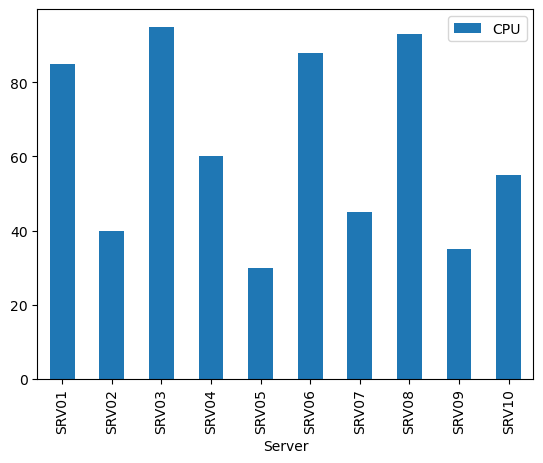

In [11]:
df.plot(
    x="Server",
    y="CPU",
    kind="bar"
)

plt.show()

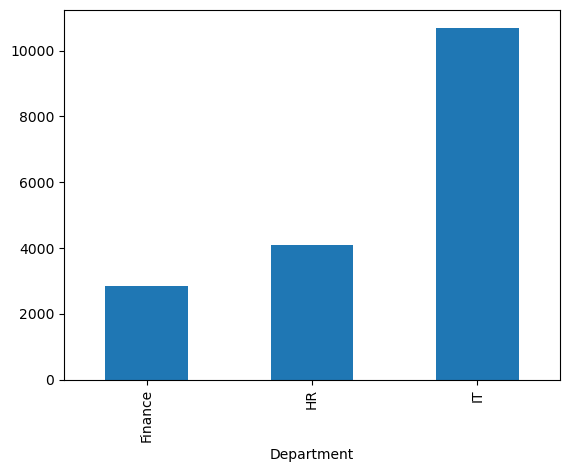

In [12]:
department_cost.plot(kind="bar")

plt.show()

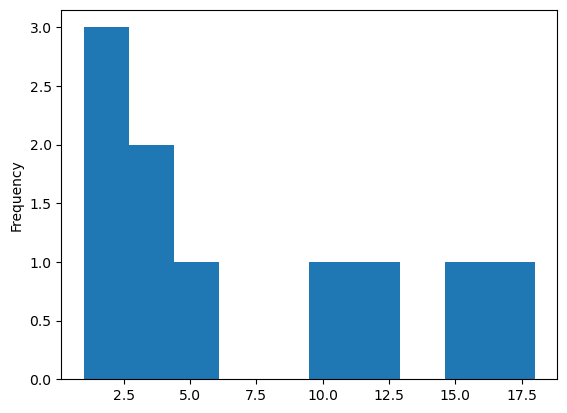

In [13]:
df["Incidents"].plot(kind="hist")

plt.show()

Key Findings

1. IT department accounts for the highest infrastructure spend.

2. SRV08 has the highest incident count.

3. SRV03 and SRV08 require scaling due to CPU utilization above 90%.

4. Finance servers show low utilization and may be candidates for cost optimization.

5. High-risk servers should be prioritized for monitoring and capacity planning.